In [65]:
import pandas as pd
import json
import plotly.express as px
import numpy as np
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn import tree

from sklearn.linear_model import LinearRegression

import xgboost as xgb

from openai import OpenAI
from config import pdf_key

In [3]:
client = OpenAI(api_key=pdf_key)
tqdm.pandas()

In [4]:
with open('./user_course_info_cleaned.json', 'r') as file:
    user_course_info = json.load(file)

df_user_course_info = pd.DataFrame(user_course_info)

In [5]:
with open('./teacher_stats_cleaned.json', 'r') as file:
    teacher_stats = json.load(file)

df_teacher_stats = pd.DataFrame(teacher_stats)

In [6]:
with open('./pro_course_cleaned.json', 'r') as file:
    pro_course = json.load(file)

df_pro_course = pd.DataFrame(pro_course)

In [7]:
with open('./price_list_cleaned.json', 'r') as file:
    price_list = json.load(file)

df_price_list = pd.DataFrame(price_list)

In [8]:
with open('./also_speaks_cleaned.json', 'r') as file:
    also_speaks = json.load(file)

df_also_speaks = pd.DataFrame(also_speaks)

In [9]:
with open('./also_speaks_reference.json', 'r') as file:
    also_speaks_reference = json.load(file)

df_also_speaks_reference = pd.DataFrame(also_speaks_reference)

AI to categorize

In [10]:
df_pro_course

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
0,375,436016,english,English courses新概念英语（1）,1400,15,106,0
1,555,436016,chinese,Young Learners' Chinese,1600,5,37,1
2,946,502096,serbian,Serbian for all levels! 100% target language l...,2300,80,1113,1
3,3190,436016,chinese,One-on-One Customized Chinese lesson,1500,73,1391,1
4,4042,463477,english,One-on-One tutoring: English,3200,95,1504,1
...,...,...,...,...,...,...,...,...
39030,290784,31481128,french,🗣️ Natural French Conversation: Speak easily !,700,0,0,1
39031,290785,8513543,french,Leçon d'essai,800,0,0,0
39032,290788,29325526,korean,For Long-term Students,1300,0,0,1
39033,290792,6417813,spanish,DELE exam preparation / Preparación para el ex...,2700,0,0,1


In [11]:
df_pro_course_category = df_pro_course.copy()
df_pro_course_category

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
0,375,436016,english,English courses新概念英语（1）,1400,15,106,0
1,555,436016,chinese,Young Learners' Chinese,1600,5,37,1
2,946,502096,serbian,Serbian for all levels! 100% target language l...,2300,80,1113,1
3,3190,436016,chinese,One-on-One Customized Chinese lesson,1500,73,1391,1
4,4042,463477,english,One-on-One tutoring: English,3200,95,1504,1
...,...,...,...,...,...,...,...,...
39030,290784,31481128,french,🗣️ Natural French Conversation: Speak easily !,700,0,0,1
39031,290785,8513543,french,Leçon d'essai,800,0,0,0
39032,290788,29325526,korean,For Long-term Students,1300,0,0,1
39033,290792,6417813,spanish,DELE exam preparation / Preparación para el ex...,2700,0,0,1


In [12]:
df_pro_course_category = df_pro_course_category.iloc[0:10]
df_pro_course_category

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
0,375,436016,english,English courses新概念英语（1）,1400,15,106,0
1,555,436016,chinese,Young Learners' Chinese,1600,5,37,1
2,946,502096,serbian,Serbian for all levels! 100% target language l...,2300,80,1113,1
3,3190,436016,chinese,One-on-One Customized Chinese lesson,1500,73,1391,1
4,4042,463477,english,One-on-One tutoring: English,3200,95,1504,1
5,5620,499227,bulgarian,"Bulgarian (levels A1, A2, B1, B2) / A 10% di...",3400,167,3872,1
6,5779,502096,english,One-on-One tutoring: English,2300,84,876,1
7,6470,517538,spanish,One to one tutoring: Let's learn Spanish toget...,2200,686,7136,1
8,7313,535501,spanish,Spanish lessons One-on-One,3100,87,1159,1
9,8425,538395,japanese,COMMUNICATIVE JAPANESE（Conversation practice),1700,215,3205,1


In [13]:
def categorize(text):
    prompt = f"""
        This is a title of a language tutoring course on italki.com. Look at the title and categorize it as one of the following categories.
        '1: Language Essentials, 2: Business, 3: Conversation or 4: Test Preparation'. Only classify and respond with the index of one of the four categories and do not give extra input.
        The title may be in languages other than English. However, only categorize them according to the options given (in English). To elaborate on the categories, 'Language Essentials' is for the fundamentals of language learning.
        'Business' refers to language use in a professional context. 'Conversation' is purely for general conversation practice. 'Test preparation' is for students
        who want to pass language accreditation exams:
        \n{text}.
        """
    resp = client.chat.completions.create(
        
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}]
    )
    return resp.choices[0].message.content

In [14]:
# df_pro_course_category["category"] = df_pro_course_category["title"].progress_apply(categorize)
# df_pro_course_category

In [15]:
# pro_course_category = df_pro_course_category.to_dict(orient='records')

# with open('./pro_course_category.json', 'w') as file:
#         json.dump(df_pro_course_category, file, indent=4)

Price Prediction Model Functions

In [244]:
def is_tutor(tutor):
    if tutor == True:
        df_tutors = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 0)]
        return df_tutors[['user_id', 'trial_session_count', 'trial_price']]
    else:
        df_pros_1 = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 1)]
        df_pros_2 = df_user_course_info[(df_user_course_info['is_tutor'] == 0) & (df_user_course_info['is_pro']  == 1)]
        df_pros_combined = pd.concat([df_pros_1, df_pros_2], ignore_index=True)
        df_pros_combined = df_pros_combined[['user_id', 'trial_session_count', 'trial_price']]
        return df_pros_combined
        
        
is_tutor(True)

,user_id,trial_session_count,trial_price
0,55502,97,1000
3,132815,0,750
6,249152,70,800
11,355886,142,500
12,368484,91,1000
...,...,...,...
10465,32167939,3,1000
10466,32168520,0,500
10467,32169200,0,1400
10468,32169731,0,600


In [17]:
def teacher_id_language(language):
    df_teachers_id = df_pro_course[df_pro_course['language'] == language].groupby(['teacher_id', 'language']).count()
    df_teachers_id = df_teachers_id.reset_index()
    df_teachers_id = df_teachers_id[['teacher_id']]
    return df_teachers_id

teacher_id_language('chinese')

,teacher_id
0,55502
1,113638
2,114708
3,259649
4,436016
...,...
993,31845535
994,31847889
995,31913484
996,31915782


In [18]:
def pro_course_language(language):
    df_pro_course_target = df_pro_course[df_pro_course['language'] == language]
    return df_pro_course_target

pro_course_language('german')

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
11,9022,516278,german,** GERMAN PROFICIENCY ★ 50 X 90 min ► All leve...,6090,84,723,1
12,9024,516278,german,★ NEXT LEVEL GERMAN ★ 40 X 90 min ► All levels...,6090,70,278,1
20,10161,516278,german,★ GERMAN IMMERSION ★ 30 X 90 min ► All levels ...,6090,46,371,1
87,20714,516278,german,Konversation,2490,211,1368,1
103,21847,222305,german,German,1499,582,3571,1
...,...,...,...,...,...,...,...,...
38971,290636,31827412,german,Relaxed German Conversation Practice for All L...,1400,0,0,1
38980,290655,31079682,german,Alemán a través de la Literatura Germana: Goet...,5000,0,0,1
38981,290656,31079682,german,"Cultura, Literatura y Actualidad Alemana – Con...",3000,0,0,1
38994,290678,18952636,german,Das Kolloquium,5000,0,0,1


In [245]:
def language_is_tutor(language, tutor):        
    df_tutor_pro = is_tutor(tutor)
    df_language = pro_course_language(language)
    df_merged = pd.merge(df_tutor_pro, df_language, left_on='user_id', right_on='teacher_id', how='inner')
    # df_merged = df_merged[['user_id', 'trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    df_merged = df_merged[['teacher_id', 'title', 'trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    # df_merged = df_merged[['trial_price', 'session_price']]
    return df_merged

language_is_tutor('french', True)

,teacher_id,title,trial_session_count,trial_price,student_count,session_count,has_package,session_price
0,614209,Français,0,1000,0,0,1,3000
1,740680,Informal Tutoring,296,1500,435,5178,1,2000
2,740680,Français pour 2,296,1500,16,238,1,2500
3,867550,French conversational practice 10 lessons package,182,800,421,2738,1,1600
4,867550,Preparing DELF/DALF exam from level A2 to C2,182,800,31,143,1,1800
...,...,...,...,...,...,...,...,...
1926,32049068,Conversation décontractée et pratique,0,500,4,7,1,1000
1927,32117853,French for Beginners – Greetings and Self-Intr...,0,500,0,0,1,700
1928,32164431,Professional French Coaching | Personalized Le...,0,2500,0,0,1,5000
1929,32167939,French Beginner A1 to C2 proficient,3,1000,0,0,0,2000


The courses that have less than 10 sessions or 10 trial sessions should be removed\
Since their progress has not yet stabilized, this should not be included in the training and test data.

In [182]:
df_model = language_is_tutor('korean', True)
df_model = df_model[(df_model['session_count'] > 10) & (df_model['trial_session_count'] > 10)]
df_model

,teacher_id,title,trial_session_count,trial_price,student_count,session_count,has_package,session_price
5,815733,Korean Conversation Practice – Speak Mostly in...,345,1500,74,538,1,3000
6,815733,"General Korean Class – From A to Z, For Everyone",345,1500,322,2045,1,3200
8,901015,Formal Korean Lessons,157,1400,30,225,1,2600
9,901015,Korean Conversation Practice,157,1400,6,26,1,2100
11,1509798,Informal Tutoring,125,1000,290,8076,1,1500
...,...,...,...,...,...,...,...,...
587,29743316,✈️ Free-Topic Conversation,17,800,4,32,1,1600
615,30615695,✨[All-in-One] Master Real-Life Korean Conversa...,14,1000,18,222,1,2200
627,30685471,🥇Structured Korean for Real-Life Communication...,22,900,15,107,1,2000
641,30742203,"한국어 회화 및 문화 | 일상생활, 케이팝, 드라마 주제 | 편안하지만 체계적인 수업",20,500,52,264,1,1000


In [183]:
df_merge = pd.merge(df_user_course_info, df_pro_course, left_on='user_id', right_on='teacher_id', how='left')
df_merge_user = df_merge.groupby('user_id')[['student_count', 'session_count']].sum()
df_merge_session_price = df_merge.groupby('user_id')[['session_price']].mean()

# df_merge = pd.merge(df_merge_user, df_merge_session_price, left_on='user_id', right_on='user_id', how='left')
# df_merge = df_merge.reset_index()
# df_merge
df_merge_user = df_merge_user.reset_index()
# df_merge_user_zero = df_merge_user[(df_merge_user['student_count'] > 50) & (df_merge_user['session_count'] > 50)]
df_merge_user_zero = df_merge_user[(df_merge_user['student_count'] > 10) & (df_merge_user['session_count'] > 10)]
df_merge_user_zero['session to student'] = df_merge_user_zero['session_count'] / df_merge_user_zero['student_count']
df_merge_user_zero = pd.merge(df_merge_user_zero, df_merge_session_price, left_on='user_id', right_on='user_id', how='left')
df_merge_user_zero = df_merge_user_zero[['user_id', 'session to student']]


df_join = pd.merge(df_model, df_merge_user_zero, left_on='teacher_id', right_on='user_id', how='left')
df_model = df_join[['trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session to student', 'session_price']]
df_model

,trial_session_count,trial_price,student_count,session_count,has_package,session to student,session_price
0,345,1500,74,538,1,6.400922,3000
1,345,1500,322,2045,1,6.400922,3200
2,157,1400,30,225,1,6.742222,2600
3,157,1400,6,26,1,6.742222,2100
4,125,1000,290,8076,1,27.848276,1500
...,...,...,...,...,...,...,...
178,17,800,4,32,1,5.250000,1600
179,14,1000,18,222,1,12.333333,2200
180,22,900,15,107,1,5.923077,2000
181,20,500,52,264,1,5.076923,1000


<Axes: >

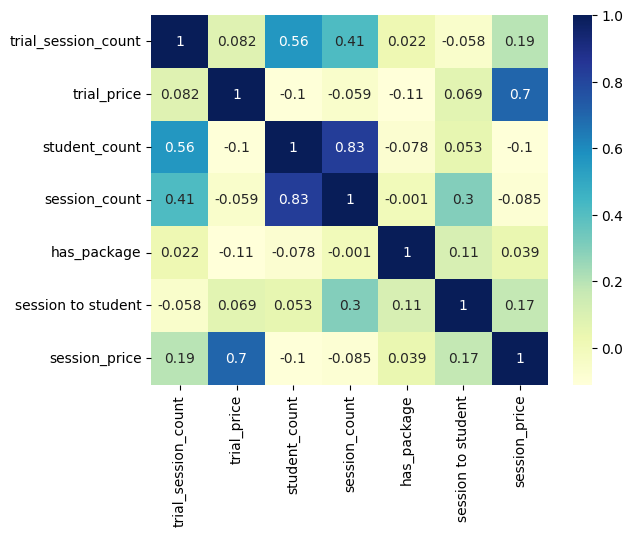

In [184]:
cor = df_model[['trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session to student', 'session_price']].corr()

#plot correlation heatmapn
sns.heatmap(cor, cmap="YlGnBu", annot=True)

In [185]:
fig = px.scatter(df_model, x="session_price", y="trial_price", trendline='ols')

# Display the interactive figure
fig.show()

In [186]:
features = list(df_model.columns)
# features.remove('title')
features.remove('session_price')
features

['trial_session_count',
 'trial_price',
 'student_count',
 'session_count',
 'has_package',
 'session to student']

In [187]:
X = df_model[features]
y = df_model['session_price']

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [189]:
regr_english_tutor = RandomForestRegressor(n_estimators=100, max_depth=50, random_state=42)
regr_english_tutor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [190]:
y_pred = regr_english_tutor.predict(X_test)

In [191]:
root_mean_squared_error(y_pred, y_test)

510.27121722071786

In [192]:
r2 = r2_score(y_test,y_pred)
r2

0.6669880996110997

Automatic checking of various models

In [197]:
language_list = ['english', 'chinese', 'french', 'spanish', 'italian', 'german', 'korean', 'japanese']

In [ ]:
def change_df_model(df_model):
    df_merge = pd.merge(df_user_course_info, df_pro_course, left_on='user_id', right_on='teacher_id', how='left')
    df_merge_user = df_merge.groupby('user_id')[['student_count', 'session_count']].sum()
    df_merge_session_price = df_merge.groupby('user_id')[['session_price']].mean()

    df_merge_user = df_merge_user.reset_index()
    df_merge_user_zero = df_merge_user[(df_merge_user['student_count'] > 10) & (df_merge_user['session_count'] > 10)]
    df_merge_user_zero['session to student'] = df_merge_user_zero['session_count'] / df_merge_user_zero['student_count']
    df_merge_user_zero = pd.merge(df_merge_user_zero, df_merge_session_price, left_on='user_id', right_on='user_id', how='left')
    df_merge_user_zero = df_merge_user_zero[['user_id', 'session to student']]


    df_join = pd.merge(df_model, df_merge_user_zero, left_on='teacher_id', right_on='user_id', how='left')
    # df_model = df_join[['trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session to student', 'session_price']]
    df_model = df_join[['trial_session_count', 'trial_price','has_package', 'session to student', 'session_price']]
    return df_model

In [217]:
def get_df_features(df_model):
    features = list(df_model.columns)
    # print(features)
    features.remove('session_price')
    return features

In [202]:
def define_X_y(df_model, features):
    X = df_model[features]
    y = df_model['session_price']
    return X, y

In [453]:
test_model = change_df_model(language_is_tutor('korean', True))
test_model
print(get_df_features(test_model))

['trial_session_count', 'trial_price', 'has_package', 'session to student']


In [295]:
models = []

In [ ]:
# do not use less than 10 students minimum
minimum_stud = 50
minimum_session = minimum_stud * 4
tutor = False
forest_depth = 20

for language in language_list:
    # train_list = []
    df_model = language_is_tutor(language, tutor)
    df_model = df_model[(df_model['session_count'] > minimum_session) & (df_model['trial_session_count'] > minimum_stud)]
    df_model = change_df_model(df_model)
    features = get_df_features(df_model)
    # print(features)
    X, y = define_X_y(df_model, features)
    # print(X, y)
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    regr = RandomForestRegressor(n_estimators=100, max_depth=forest_depth, random_state=42)
    # regr = RandomForestRegressor(n_estimators=100, random_state=42)
    regr.fit(X_train, y_train)

    y_pred = regr.predict(X_test)
    r2 = round(r2_score(y_test,y_pred),2)

    rmse = round(root_mean_squared_error(y_pred, y_test), 2)

    each_language = {'language': language,
                      'RMSE': rmse,
                      'R-Squared': r2,
                      'forest_depth': forest_depth,
                       'minimum_students': minimum_stud,
                       'minimum_session': minimum_session,
                       'tutor': tutor }
    models.append(each_language)

    # print(language)
    # print('RMSE:', rmse)
    # print('R-Squared', round(r2, 2))

df_models_attempts = pd.DataFrame(models)
# df_models_attempts.sort_values(['RMSE', 'R-Squared'])

In [443]:
models_attempts_records = df_models_attempts.to_dict(orient='records')

In [444]:
with open('./prediction_model_records.json', 'w') as file:
        json.dump(models_attempts_records, file, indent=4)

In [442]:
df_models_attempts.sort_values(['RMSE', 'R-Squared'])

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
121,chinese,297.58,0.79,10,50,150,True
281,chinese,300.42,0.78,20,50,150,True
81,chinese,304.77,0.69,10,50,100,True
145,chinese,307.48,0.73,10,30,120,True
305,chinese,307.58,0.73,20,30,120,True
...,...,...,...,...,...,...,...
394,french,1203.75,0.49,10,40,80,False
158,korean,1757.48,0.16,10,40,160,True
318,korean,1765.12,0.15,20,40,160,True
286,korean,1767.49,0.17,20,50,150,True


In [459]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'english') & (df_sorted_models['tutor'] == False)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
600,english,642.22,0.77,20,50,150,False
624,english,644.18,0.78,20,30,120,False
464,english,698.84,0.74,10,30,120,False
440,english,699.21,0.73,10,50,150,False
560,english,717.77,0.72,20,50,100,False
528,english,722.82,0.72,20,10,20,False
576,english,760.45,0.70,20,20,60,False
536,english,762.87,0.72,20,20,40,False
640,english,769.18,0.72,20,50,200,False
400,english,769.93,0.68,10,50,100,False


In [458]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'chinese') & (df_sorted_models['tutor'] == False)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
601,chinese,471.63,0.82,20,50,150,False
441,chinese,473.52,0.82,10,50,150,False
473,chinese,498.08,0.73,10,40,160,False
633,chinese,511.77,0.71,20,40,160,False
497,chinese,512.09,0.77,20,20,20,False
465,chinese,520.35,0.77,10,30,120,False
337,chinese,524.04,0.76,10,20,20,False
625,chinese,527.04,0.77,20,30,120,False
513,chinese,572.52,0.73,20,40,40,False
641,chinese,576.54,0.83,20,50,200,False


In [463]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'french') & (df_sorted_models['tutor'] == True)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
234,french,468.62,0.76,20,40,80,True
258,french,469.70,0.78,20,20,60,True
322,french,471.87,0.71,20,50,200,True
162,french,472.20,0.71,10,50,200,True
74,french,481.36,0.75,10,40,80,True
98,french,486.28,0.77,10,20,60,True
218,french,524.42,0.73,20,20,40,True
210,french,543.15,0.78,20,10,20,True
186,french,544.56,0.66,20,30,30,True
18,french,548.20,0.66,10,30,30,True


In [465]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'spanish') & (df_sorted_models['tutor'] == True)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
283,spanish,320.76,0.77,20,50,150,True
275,spanish,322.15,0.68,20,40,120,True
123,spanish,339.36,0.74,10,50,150,True
115,spanish,339.75,0.65,10,40,120,True
315,spanish,346.42,0.66,20,40,160,True
203,spanish,348.59,0.74,20,50,50,True
227,spanish,362.43,0.76,20,30,60,True
35,spanish,366.92,0.71,10,50,50,True
307,spanish,368.04,0.68,20,30,120,True
155,spanish,370.03,0.61,10,40,160,True


In [467]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'german') & (df_sorted_models['tutor'] == True)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
165,german,501.86,0.63,10,50,200,True
325,german,522.04,0.60,20,50,200,True
253,german,544.80,0.67,20,10,30,True
93,german,550.16,0.67,10,10,30,True
261,german,556.53,0.69,20,20,60,True
101,german,560.60,0.69,10,20,60,True
285,german,570.21,0.72,20,50,150,True
125,german,571.41,0.71,10,50,150,True
109,german,617.32,0.55,10,30,90,True
173,german,620.96,0.53,20,10,10,True


In [469]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'italian') & (df_sorted_models['tutor'] == True)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
212,italian,487.00,0.70,20,10,20,True
44,italian,488.81,0.70,10,10,20,True
52,italian,488.81,0.70,10,10,20,True
172,italian,511.45,0.73,20,10,10,True
12,italian,515.88,0.71,10,20,20,True
180,italian,516.97,0.71,20,20,20,True
4,italian,518.33,0.72,10,10,10,True
204,italian,535.03,0.79,20,50,50,True
36,italian,541.67,0.78,10,50,50,True
60,italian,559.78,0.75,10,20,40,True


In [470]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'japanese') & (df_sorted_models['tutor'] == False)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
583,japanese,578.50,0.79,20,20,60,False
551,japanese,590.74,0.74,20,30,60,False
391,japanese,591.14,0.74,10,30,60,False
423,japanese,598.73,0.77,10,20,60,False
631,japanese,616.62,0.78,20,30,120,False
591,japanese,633.35,0.79,20,30,90,False
471,japanese,634.44,0.77,10,30,120,False
431,japanese,648.57,0.78,10,30,90,False
511,japanese,652.89,0.74,20,30,30,False
351,japanese,666.67,0.73,10,30,30,False


In [472]:
df_sorted_models = df_models_attempts.sort_values(['RMSE', 'R-Squared'])
df_sorted_models[(df_sorted_models['language'] == 'korean') & (df_sorted_models['tutor'] == True)].head(10)

,language,RMSE,R-Squared,forest_depth,minimum_students,minimum_session,tutor
38,korean,367.01,0.92,10,50,50,True
294,korean,381.67,0.81,20,10,40,True
134,korean,383.86,0.81,10,10,40,True
118,korean,396.83,0.92,10,40,120,True
278,korean,398.82,0.92,20,40,120,True
206,korean,400.40,0.91,20,50,50,True
22,korean,407.99,0.91,10,30,30,True
190,korean,409.48,0.91,20,30,30,True
310,korean,415.74,0.89,20,30,120,True
46,korean,416.76,0.78,10,10,20,True


Different Model Considering Session to Student Ratio and per teacher level

In [110]:
df_merge = pd.merge(df_user_course_info, df_pro_course, left_on='user_id', right_on='teacher_id', how='left')
df_merge_user = df_merge.groupby('user_id')[['student_count', 'session_count']].sum()
df_merge_session_price = df_merge.groupby('user_id')[['session_price']].mean()

# df_merge = pd.merge(df_merge_user, df_merge_session_price, left_on='user_id', right_on='user_id', how='left')
# df_merge = df_merge.reset_index()
# df_merge
df_merge_user = df_merge_user.reset_index()
# df_merge_user_zero = df_merge_user[(df_merge_user['student_count'] > 50) & (df_merge_user['session_count'] > 50)]
df_merge_user_zero = df_merge_user[(df_merge_user['student_count'] > 0) & (df_merge_user['session_count'] > 0)]
df_merge_user_zero['session to student'] = df_merge_user_zero['session_count'] / df_merge_user_zero['student_count']
df_merge_user_zero = pd.merge(df_merge_user_zero, df_merge_session_price, left_on='user_id', right_on='user_id', how='left')
df_merge_user_zero


,user_id,student_count,session_count,session to student,session_price
0,55502,205,2562,12.497561,2100.000000
1,113638,456,7726,16.942982,3000.000000
2,114708,10,44,4.400000,2090.000000
3,132815,235,1980,8.425532,1860.000000
4,148092,273,3897,14.274725,2700.000000
...,...,...,...,...,...
10115,32102519,1,2,2.000000,1000.000000
10116,32106062,3,3,1.000000,1083.333333
10117,32113662,2,2,1.000000,1200.000000
10118,32113766,2,2,1.000000,1225.000000


In [111]:
teacher_id_language('chinese')

,teacher_id
0,55502
1,113638
2,114708
3,259649
4,436016
...,...
993,31845535
994,31847889
995,31913484
996,31915782


In [117]:
def choose_language_teachers_model(language):
    df_teachers_id = teacher_id_language(language)
    df_merge = pd.merge(df_teachers_id, df_merge_user_zero, left_on='teacher_id', right_on='user_id', how='left')
    df_merge = df_merge[df_merge['student_count'] > 0]
    return df_merge

In [113]:
df_model

,teacher_id,user_id,student_count,session_count,session to student,session_price
0,132815,132815,235,1980,8.425532,1860.000000
1,815733,815733,434,2778,6.400922,3050.000000
2,901015,901015,225,1517,6.742222,2412.500000
3,948628,948628,540,7322,13.559259,2666.666667
4,961354,961354,600,13361,22.268333,1700.000000
...,...,...,...,...,...,...
533,32098917,32098917,0,0,NaN,2550.000000
534,32099223,32099223,0,0,NaN,1400.000000
535,32101494,32101494,0,0,NaN,1500.000000
536,32102519,32102519,1,2,2.000000,1000.000000


In [118]:
df_model = choose_language_teachers_model('korean')

features = list(df_model.columns)
features.remove('user_id')
features.remove('session_price')
features.remove('student_count')
features.remove('session_count')
features.remove('teacher_id')
features

['session to student']

In [119]:
X = df_model[features]
y = df_model['session_price']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [121]:
teacher_model = RandomForestRegressor(n_estimators=100, max_depth=50, random_state=42)
teacher_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [122]:
y_pred = teacher_model.predict(X_test)

In [123]:
root_mean_squared_error(y_pred, y_test)

1084.7461235371886

In [124]:
r2 = r2_score(y_test,y_pred)
r2

0.006495145633802157

Linear Regression Model

In [125]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [126]:
root_mean_squared_error(y_pred, y_test)

1084.7461235371886

In [127]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [128]:
root_mean_squared_error(y_pred, y_test)

1176.397451118769

In [129]:
r2 = r2_score(y_test,y_pred)
r2

-0.16848173880152228